# Experimentos de Variação de Hiperparâmetros do Decodificador

Este notebook executa os 5 experimentos de variação da arquitetura do decodificador, conforme solicitado no projeto.

# Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Imports e Configurações Iniciais
import torch
from pathlib import Path
from torchvision.models import resnet50, ResNet50_Weights
import src.models as models
import src.train as train
import src.model_evaluation as me
import numpy as np


# Configurações
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "./data/oxford_pets"
CHECKPOINT_ROOT = Path("./checkpoints")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


## Download Dataset Oxford Pets


In [32]:
from torchvision.datasets.utils import download_and_extract_archive

def download(root):
    url_images = "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz"
    url_targets = "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz"
    download_and_extract_archive(url_images, root, remove_finished=False)
    download_and_extract_archive(url_targets, root, remove_finished=False)

# Descomente a linha abaixo para baixar o dataset Oxford Pets
# download('./data/oxford_pets')

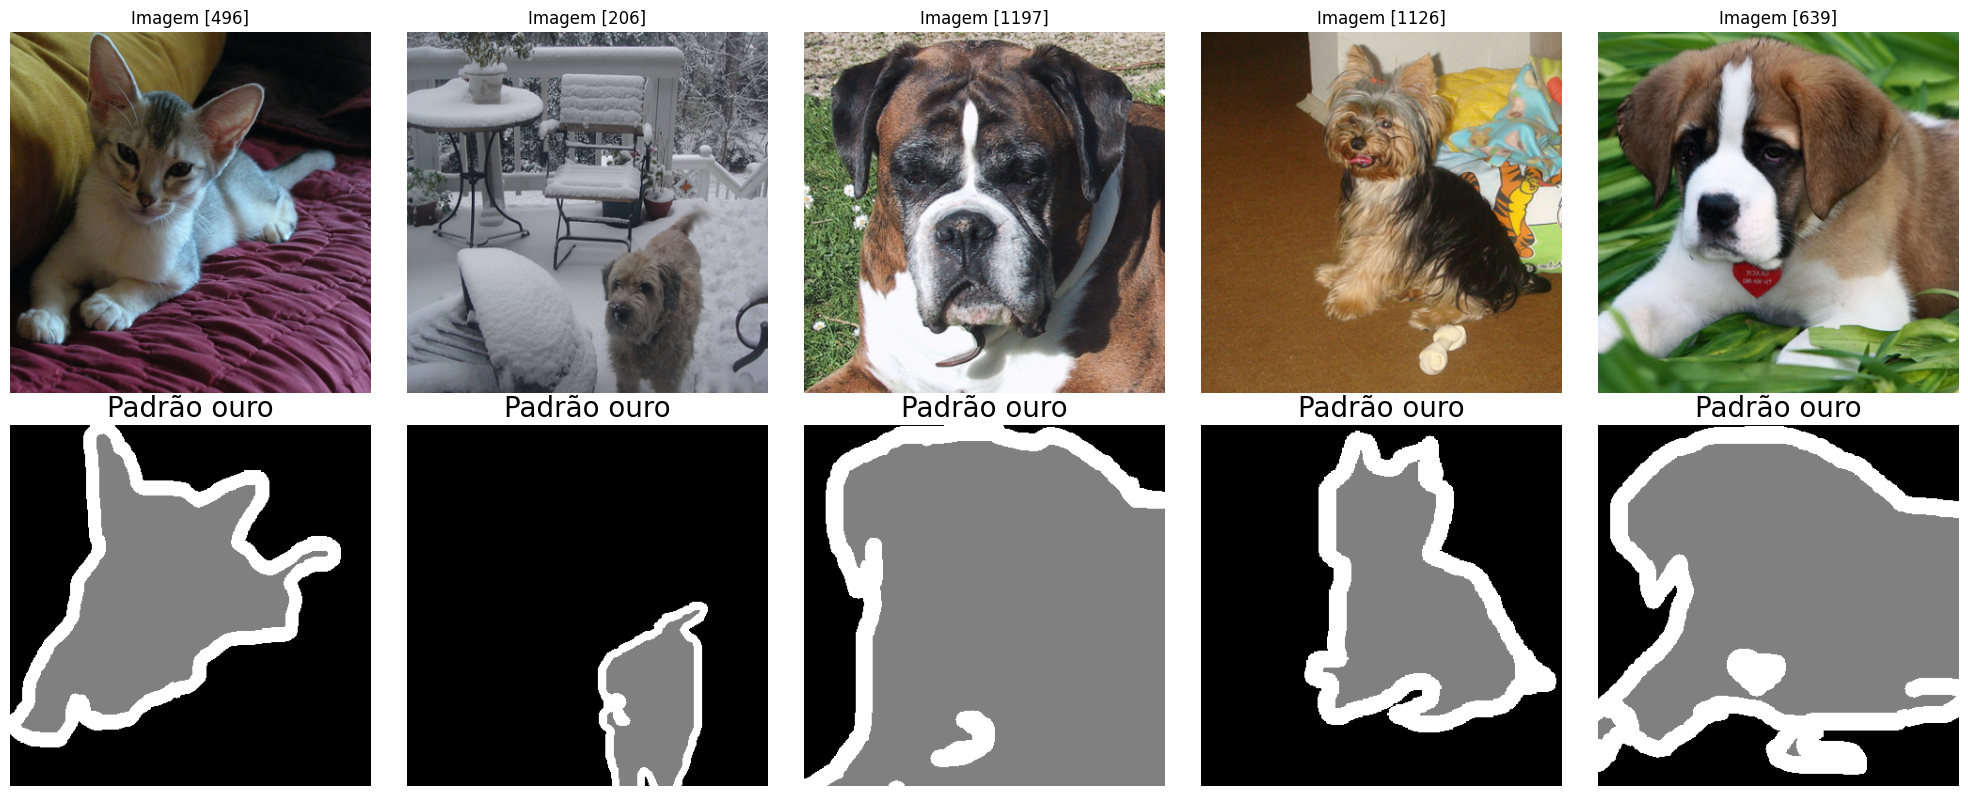

In [31]:
indices = np.random.choice(range(1468), 5, replace=False)
me.plot_image_and_gt_grid(DATA_ROOT, indices=indices, split="train", save_pdf=True, pdf_path="image_gt_grid_.pdf")

# 1. Experimentos de Variação de Hiperparâmetros do Decodificador

```python

## Carrega o codificador pré-treinado

In [33]:
# Carrega o codificador pré-treinado e o configura para não ser treinável
encoder = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
for param in encoder.parameters():
    param.requires_grad = False
encoder.to(DEVICE)
encoder.eval();

## Define os parâmetros dos experimentos de variação dos strides

Aqui são definidos os parâmetros dos experimentos de variação dos strides do decodificador. Cada configuração de strides será testada para avaliar seu impacto na segmentação.

```python

In [ ]:

# Cada dicionário na lista representa um dos experimentos solicitados.
experiments = [
    {
        "name": "strides_32",
        "params": {"use_strides": [32], "extra_convs": False}
    }, 
    {
        "name": "strides_2",
        "params": {"use_strides": [2], "extra_convs": False}
    },
    {
        "name": "strides_2_32",
        "params": {"use_strides": [2, 32], "extra_convs": False}
    },
    {
        "name": "strides_2_8_32",
        "params": {"use_strides": [2, 8, 32], "extra_convs": False}
    },
    {
        "name": "strides_2_32_extra_convs",
        "params": {"use_strides": [2, 32], "extra_convs": True}
    }
]


## Treinamento do decodificador

Nesta fase, iremos treinar o decodificador com as diferentes configurações de strides. O treinamento será realizado para cada configuração definida anteriormente com os seguintes hiperparâmetros:

In [ ]:
training_params = {
    "bs_train": 128,
    "bs_valid": 16,
    "num_epochs": 10, # Pode aumentar para 30-50 para melhores resultados
    "lr": 1e-2,
    "weight_decay": 1e-3,
    "resize_size": 256,
    "num_workers": 8
}

In [ ]:
# Parâmetros do wandb
USE_WANDB = True  # Coloque False se não quiser logar no wandb
WANDB_PROJECT = "cv-project-decoder-hyperparam-variation"
WANDB_GROUP = None
META = None

for exp_config in experiments:
    # Configuração do experimento
    name = exp_config["name"]
    # Parâmetros específicos do experimento
    params = exp_config["params"]
    
    print(f"\n{'='*50}")
    print(f"INICIANDO EXPERIMENTO: {name}")
    print(f"Parâmetros do modelo: {params}")
    print(f"{'='*50}\n")

    exp_checkpoint_dir = CHECKPOINT_ROOT / name
    exp_checkpoint_dir.mkdir(parents=True, exist_ok=True)
    
    model = models.EncoderDecoder(
        resnet_encoder=encoder,
        decoder_channels=64,
        num_classes=2,  # Ajuste conforme seu problema
        **params
    )
    
    train.train(
        model=model,
        checkpoint_dir=str(exp_checkpoint_dir),
        data_root=DATA_ROOT,
        use_wandb=USE_WANDB,
        wandb_project=WANDB_PROJECT,
        run_name=name,  # nome da run igual ao experimento
        experiment_name=name,  # pode ser igual ao nome do experimento
        **training_params
    )
    
    print(f"\n{'='*50}")
    print(f"EXPERIMENTO {name} CONCLUÍDO!")
    print(f"Checkpoints salvos em: {exp_checkpoint_dir}")
    print(f"{'='*50}\n")

print("Todos os experimentos foram concluídos.")

# 2. Avaliação dos Resultados

Nesta fase, iremos avaliar os resultados dos experimentos realizados. A avaliação será feita com base nas métricas de desempenho obtidas durante o treinamento e validação. Para isso, iremos carregar os checkpoints dos experimentos e calcular as métricas de desempenho e então sumariar os resultados.

```python

In [13]:
df_perf = me.evaluate_models_performance(CHECKPOINT_ROOT, DATA_ROOT, experiments)

/home/wesleygalvao/Insync/wesleygalvao@estudante.ufscar.br/Google Drive/Mestrado - Visão Computacional/Disciplinas/Visão Computacional/computer-vision-projects/02_decoder_hyperparam_variation/src/model_evaluation.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded

In [14]:
df_perf.to_csv("performance_summary.csv", index=False)
df_perf

,model,mean_iou,std_iou,n_params,total_inference_time_s,avg_inference_time_s,dataset_size
0,strides_32,0.676613,0.130273,26737962,13.927792,0.009481,1469
1,strides_2,0.406865,0.199718,25595178,14.073158,0.009580,1469
2,strides_2_32,0.700647,0.128152,26779178,14.233619,0.009689,1469
3,strides_2_8_32,0.728782,0.122306,26849066,14.777478,0.010060,1469
4,strides_2_32_extra_convs,0.705579,0.128391,26816170,14.751863,0.010042,1469


Finalmente, podemos avaliar os resultados qualitativos dos experimentos, visualizando as previsões do modelo em algumas imagens de teste e comparando as segmentações geradas pelos diferentes decodificadores em cada experimento.

```python
```

[1084  353  516 1047 1091]


/home/wesleygalvao/Insync/wesleygalvao@estudante.ufscar.br/Google Drive/Mestrado - Visão Computacional/Disciplinas/Visão Computacional/computer-vision-projects/02_decoder_hyperparam_variation/src/model_evaluation.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded

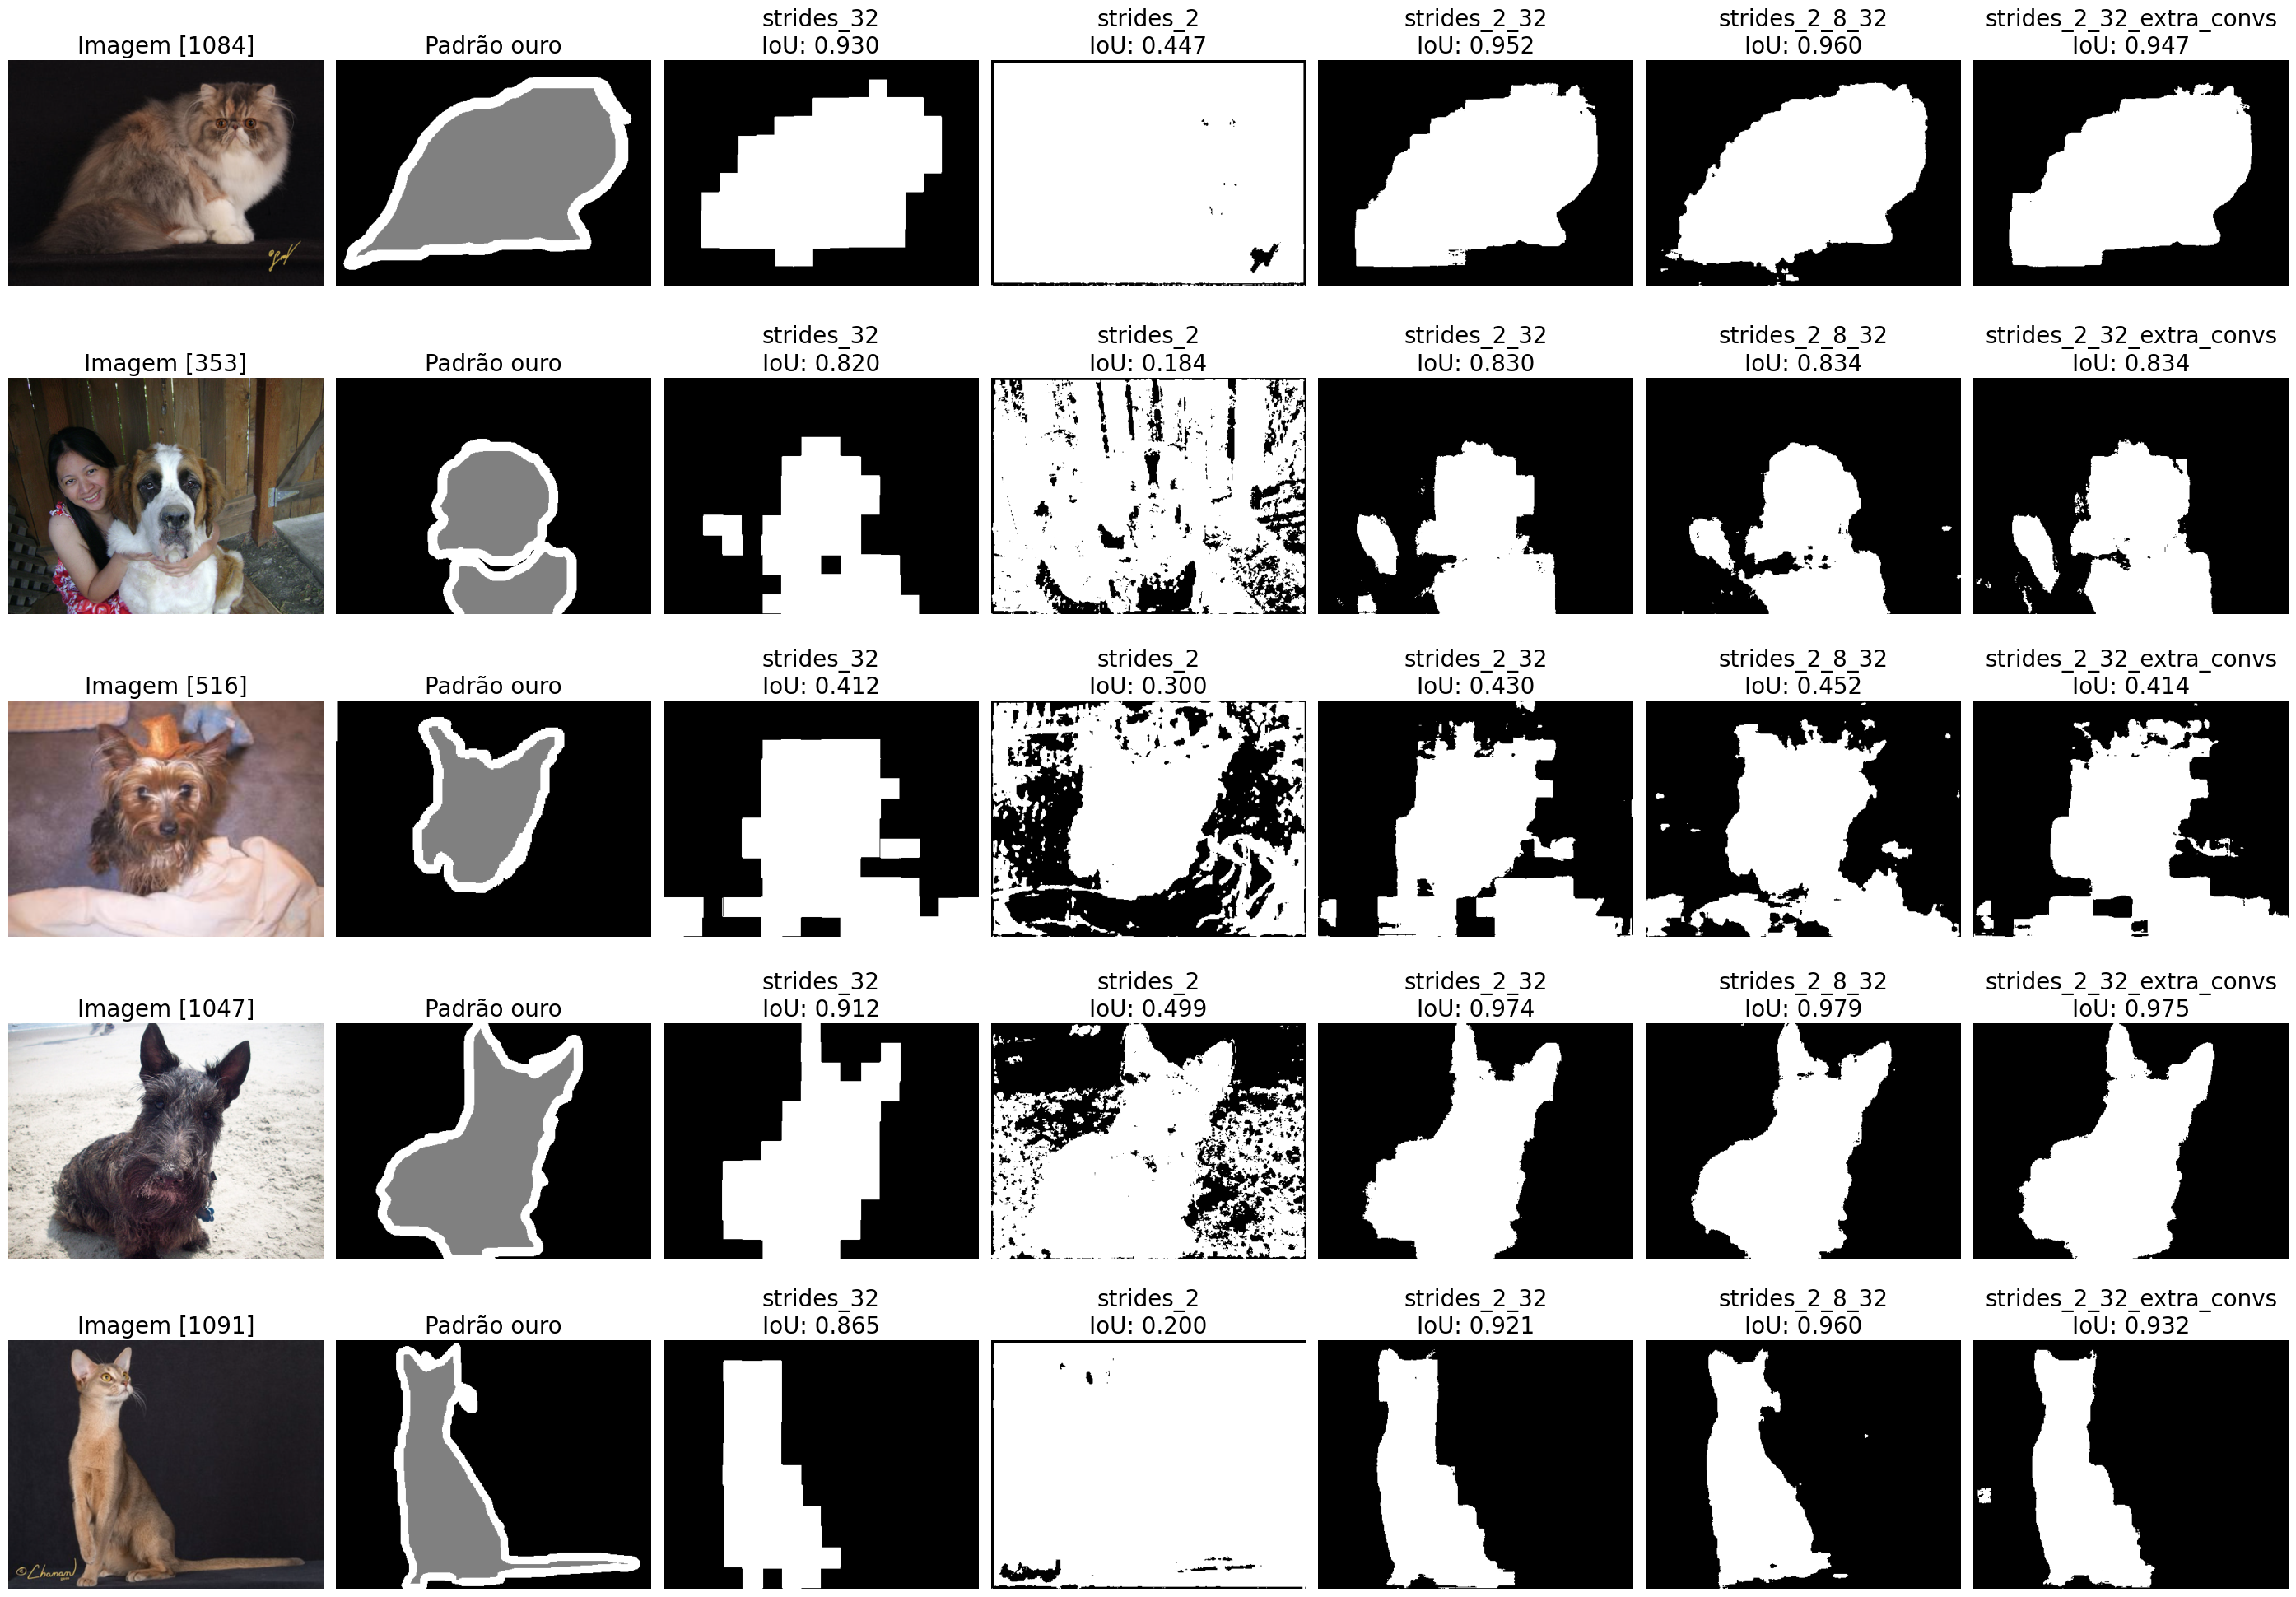

In [29]:
indices = np.random.choice(range(1468), 5, replace=False)
print(indices)
me.plot_model_segmentations(CHECKPOINT_ROOT, DATA_ROOT, experiments, indices=indices, save_pdf=True, pdf_path="segmentations_.pdf")